# Зачет

Выполнил:   
Группа: ИД24-3    
Вариант: 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

### 1.	Получить набор данных для анализа. Идентифицировать и описать задачу машинного обучения. Описать этот набор и решаемую задачу. Выделить целевую переменную и атрибуты.

In [5]:
a = datasets.load_iris()

In [7]:
print(a.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Количество наблюдений: 150 (по 50 в каждом из трех классов)
Количество атрибутов: 4 числовых, прогностических атрибута и класс
Информация об атрибутах:

- длина чашелистика в см

- ширина чашелистика в см

- длина лепестка в см

- ширина лепестка в см
   
Классы:

- Iris-Setosa

- Iris-Versicolour

- Iris-Virginica

Задачи машинного обучения - классификация, тк целевая переменная является категориальной (дискретной). Мы предсказываем не непрерывное число, а метку из конечного набора: {'Setosa', 'Versicolor', 'Virginica'}

Ключи

In [12]:
a.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Классы

In [15]:
a.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [17]:
df = pd.DataFrame(data = a.data, columns = a.feature_names)
df['target'] = a.target

In [19]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [21]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [25]:
X = a.data
y = a.target

In [27]:
print(f'чисто строк(объектов): {X.shape[0]}')
print(f'число признаков(столбцов): {X.shape[1]}')

чисто строк(объектов): 150
число признаков(столбцов): 4


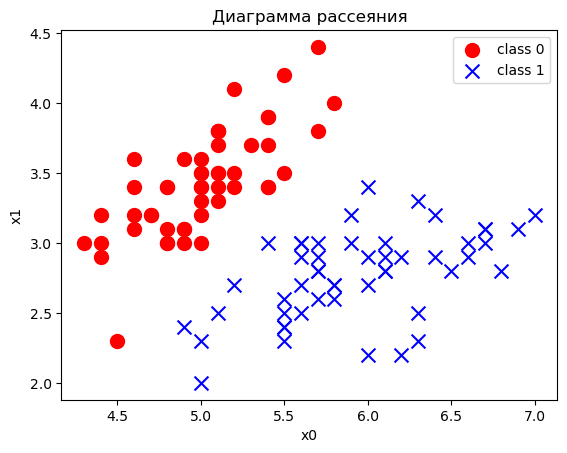

In [29]:
plt.title("Диаграмма рассеяния")
plt.xlabel('x0')
plt.ylabel('x1')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100, label='class 0')
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100, label='class 1')

plt.legend()
plt.show()

### 2.	Разделить набор данных на обучающую и тестовую выборки.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42,stratify = y)

### 3.	Обучить несколько моделей для решения выбранной задачи (для задач классификации - не менее 7 различных алгоритмов (одну модель построите на двух факторных признаках), для задачи регрессии - не менее 5). Оценивается количество и разнообразие моделей.

In [35]:
scaler = StandardScaler()

In [37]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Выберем два информативных признака (petal length и petal width)

In [40]:
X_two_features = X[:, [2, 3]]

In [42]:
X_train_two, X_test_two, y_train_two, y_test_two = train_test_split(X_two_features, y, test_size=0.3, random_state=42, stratify=y)

X_train_two_scaled = scaler.fit_transform(X_train_two)
X_test_two_scaled = scaler.transform(X_test_two)

#### Логистическая ререссия

In [45]:
log_reg = LogisticRegression(max_iter=200, random_state=42)

In [47]:
log_reg.fit(X_train,y_train)

LogisticRegression(max_iter=200, random_state=42)

In [49]:
y_pred_log_reg = log_reg.predict(X_test)

In [51]:
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f'accuracy: {acc_log_reg}')

accuracy: 0.9333333333333333


#### k - ближайших соседей

In [54]:
knn = KNeighborsClassifier(n_neighbors=5)

In [56]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [58]:
y_pred_knn= knn.predict(X_test)

In [60]:
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f'accuracy: {acc_knn}')

accuracy: 0.9777777777777777


#### Дерево решений

In [63]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)

In [65]:
tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [67]:
y_pred_tree = tree.predict(X_test)

In [69]:
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f'accuracy: {acc_tree}')

accuracy: 0.9777777777777777


#### Метод опорных векторов (SVM) с радиальным ядром

In [72]:
svm = SVC(kernel='rbf', probability=True, random_state=42)

In [74]:
svm.fit(X_train,y_train)

SVC(probability=True, random_state=42)

In [76]:
y_pred_svm= svm.predict(X_test)

In [78]:
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f'accuracy: {acc_svm}')

accuracy: 0.9555555555555556


#### Наивный байесовский классификатор

In [81]:
nb = GaussianNB()

In [83]:
nb.fit(X_train,y_train)

GaussianNB()

In [85]:
y_pred_nb= nb.predict(X_test)

In [87]:
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f'accuracy: {acc_nb}')

accuracy: 0.9111111111111111


#### Случайный лес

In [90]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [92]:
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [93]:
y_pred_rf = rf.predict(X_test)

In [96]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'accuracy: {acc_rf}')

accuracy: 0.8888888888888888


#### Многослойный перцептрон (MLP)

In [99]:
mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

In [101]:
mlp.fit(X_train,y_train)

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

In [102]:
y_pred_mlp = mlp.predict(X_test)

In [103]:
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f'accuracy: {acc_mlp}')

accuracy: 1.0


#### SVM c линейнымядром на двух признаках

In [108]:
svm_two = SVC(kernel='linear', probability=True, random_state=42)

In [110]:
svm_two.fit(X_train_two_scaled,y_train_two)

SVC(kernel='linear', probability=True, random_state=42)

In [112]:
y_pred_svm_two= svm_two.predict(X_test_two_scaled)

In [114]:
acc_svm_two = accuracy_score(y_test_two, y_pred_svm_two)
print(f'accuracy: {acc_svm_two}')

accuracy: 0.9111111111111111


### 4.	Оценить каждую из выбранных моделей по как можно большему количеству метрик эффективности. Для модели классификации, обученной на двух факторных признаков обязательно построить разделяющую поверхность. Для моделей регрессии - график зависимости теоретических значений от эмпирических.

In [117]:
print(f'accuracy: {acc_log_reg}')
print(f'F1 score:{f1_score(y_test, y_pred_log_reg, average='macro')}')

accuracy: 0.9333333333333333
F1 score:0.9332591768631814


<Axes: >

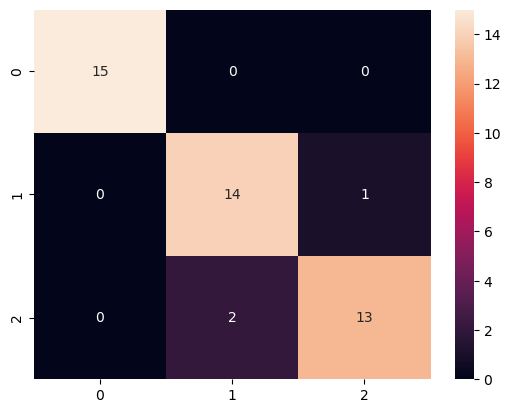

In [119]:
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True)

In [120]:
print(f'accuracy: {acc_knn}')
print(f'F1 score:{f1_score(y_test, y_pred_knn, average='macro')}')

accuracy: 0.9777777777777777
F1 score:0.9777530589543938


<Axes: >

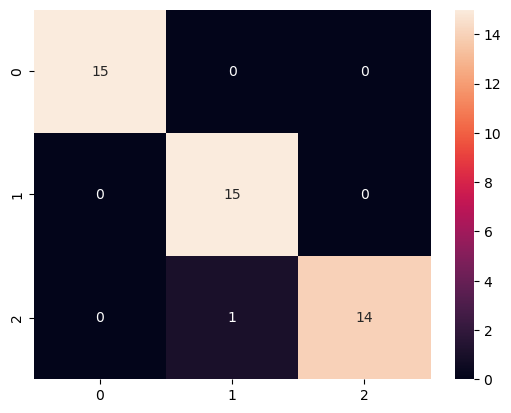

In [123]:
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True)

In [124]:
print(f'accuracy: {acc_tree}')
print(f'F1 score:{f1_score(y_test, y_pred_tree, average='macro')}')

accuracy: 0.9777777777777777
F1 score:0.9777530589543938


<Axes: >

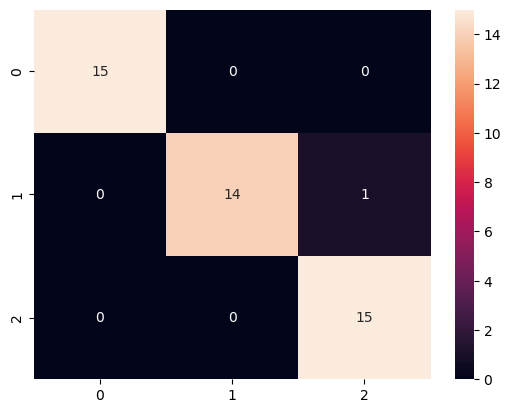

In [127]:
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True)

In [129]:
print(f'accuracy: {acc_svm}')
print(f'F1 score:{f1_score(y_test, y_pred_svm, average='macro')}')

accuracy: 0.9555555555555556
F1 score:0.9555555555555556


<Axes: >

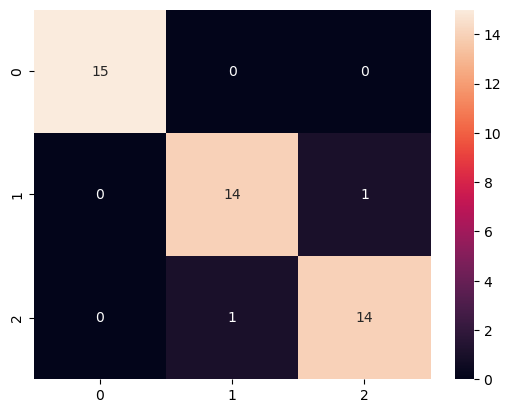

In [131]:
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True)

In [132]:
print(f'accuracy: {acc_nb}')
print(f'F1 score:{f1_score(y_test, y_pred_nb, average='macro')}')

accuracy: 0.9111111111111111
F1 score:0.9107142857142857


<Axes: >

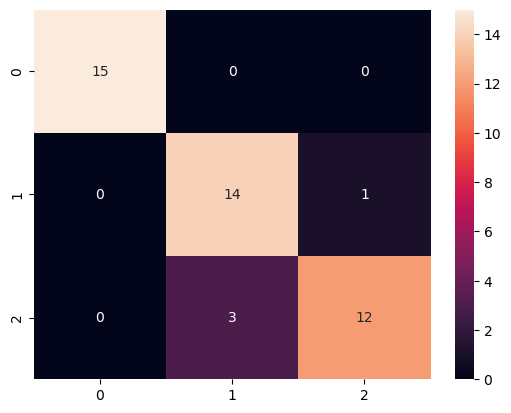

In [135]:
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True)

In [136]:
print(f'accuracy: {acc_rf}')
print(f'F1 score:{f1_score(y_test, y_pred_rf, average='macro')}')

accuracy: 0.8888888888888888
F1 score:0.8877665544332212


<Axes: >

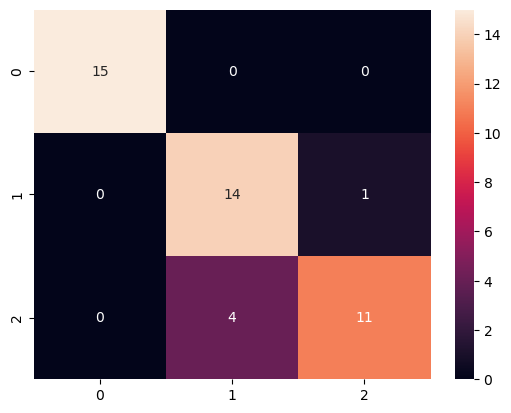

In [139]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True)

In [140]:
print(f'accuracy: {acc_mlp}')
print(f'F1 score:{f1_score(y_test, y_pred_mlp, average='macro')}')

accuracy: 1.0
F1 score:1.0


<Axes: >

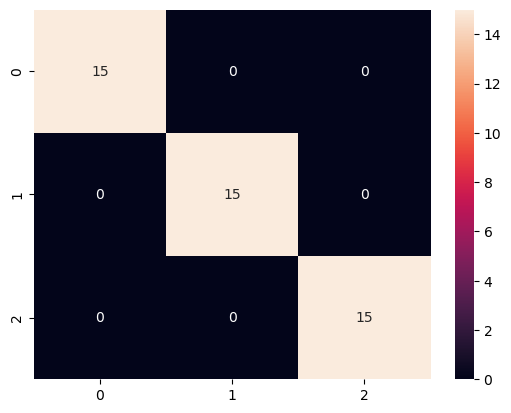

In [143]:
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True)

In [144]:
print(f'accuracy: {acc_svm_two}')
print(f'F1 score:{f1_score(y_test, y_pred_svm_two, average='macro')}')

accuracy: 0.9111111111111111
F1 score:0.9107142857142857


<Axes: >

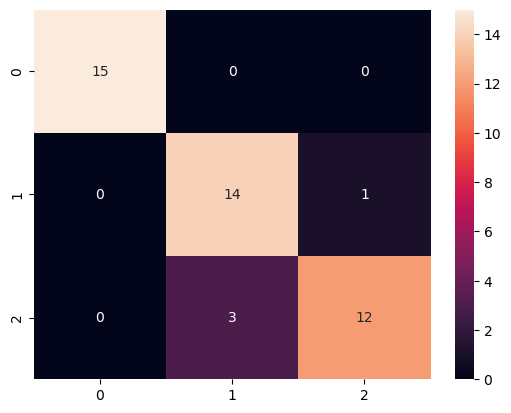

In [147]:
sns.heatmap(confusion_matrix(y_test, y_pred_svm_two), annot=True)

#### Для модели на двух признаках

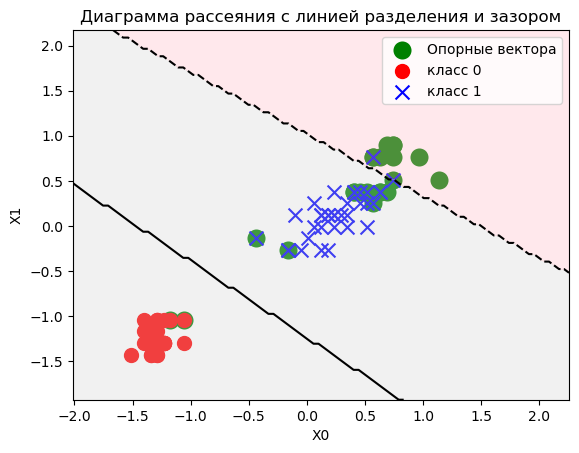

In [150]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green', label = 'Опорные вектора')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100, label = 'класс 0')
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100, label = 'класс 1')

    X0 = np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 100)
    X1 = np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 100)

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    grid_points = np.column_stack([X0_grid.ravel(), X1_grid.ravel()])
    Z = model.predict(grid_points).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, levels=[-np.inf, -1, 1, np.inf], colors=['lightblue', 'lightgray', 'lightpink'], alpha=0.3)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.legend()
    plt.show()


plot_decision_regions(X_train_two_scaled, y_train_two, svm_two)

### 5.	Оценка моделей должно проводиться на тестовой выборке. Для каждой модели нужно проанализировать эффективность на обучающей выборке справочно.

In [153]:
def calculate_metrics(model_name, y_true, y_pred, y_train_true=None, y_train_pred=None):
    metrics = {
        'model': model_name,
        'test_accuracy': accuracy_score(y_true, y_pred),
        'test_f1_macro': f1_score(y_true, y_pred, average='macro'),
        'test_precision_macro': precision_score(y_true, y_pred, average='macro'),
        'test_recall_macro': recall_score(y_true, y_pred, average='macro'),
    }

    if y_train_true is not None and y_train_pred is not None:
        metrics['train_accuracy'] = accuracy_score(y_train_true, y_train_pred)
        metrics['train_f1_macro'] = f1_score(y_train_true, y_train_pred, average='macro')
        metrics['accuracy_diff'] = metrics['train_accuracy'] - metrics['test_accuracy']

    return metrics

In [155]:
all_metrics = []
models_info = [
    ('Логистическая регрессия', y_test, y_pred_log_reg, y_train, log_reg.predict(X_train)),
    ('K-ближайших соседей knn', y_test, y_pred_knn, y_train, knn.predict(X_train)),
    ('Дерево решений', y_test, y_pred_tree, y_train, tree.predict(X_train)),
    ('Метод опорных векторов', y_test, y_pred_svm, y_train, svm.predict(X_train)),
    ('Наивный Байес', y_test, y_pred_nb, y_train, nb.predict(X_train)),
    ('Случайный лес', y_test, y_pred_rf, y_train, rf.predict(X_train)),
    ('Нейронная сеть MLP', y_test, y_pred_mlp, y_train, mlp.predict(X_train))]

for model_name, y_test_vals, y_pred, y_train_vals, y_train_pred in models_info:
    metrics = calculate_metrics(model_name, y_test_vals, y_pred, y_train_vals, y_train_pred)
    all_metrics.append(metrics)

metrics_svm_two = calculate_metrics('SVM на 2 признаках', y_test_two, y_pred_svm_two, y_train_two, svm_two.predict(X_train_two))

all_metrics.append(metrics_svm_two)

In [157]:
results_df = pd.DataFrame(all_metrics)

### 6.	Составить итоговую таблицу эффективности моделей, в которую свести все численные метрики. Сделать вывод о применимости моделей для решения конкретной поставленной задачи.

In [160]:
results_df

,model,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,train_accuracy,train_f1_macro,accuracy_diff
0,Логистическая регрессия,0.933333,0.933259,0.934524,0.933333,0.971429,0.971423,0.038095
1,K-ближайших соседей knn,0.977778,0.977753,0.979167,0.977778,0.971429,0.971423,-0.006349
2,Дерево решений,0.977778,0.977753,0.979167,0.977778,0.980952,0.980952,0.003175
3,Метод опорных векторов,0.955556,0.955556,0.955556,0.955556,0.971429,0.971423,0.015873
4,Наивный Байес,0.911111,0.910714,0.915535,0.911111,0.980952,0.980952,0.069841
5,Случайный лес,0.888889,0.887767,0.898148,0.888889,1.000000,1.000000,0.111111
6,Нейронная сеть MLP,1.000000,1.000000,1.000000,1.000000,0.971429,0.971376,-0.028571
7,SVM на 2 признаках,0.911111,0.910714,0.915535,0.911111,0.333333,0.167866,-0.577778


Лучшая модель по точности на тестовой выборке - MLP (точность - 100%) Чуть хуже модели KNN и дерево решений (около 97%) У метода опорных векторов, логистической регрессии и наивного Байеса точность 90-95% Модель случайного леса работает хуже остальныз (88.9%) и не рекомендуется для данной задачи